# Pharma Pricing Copilot — Exploratory Data Analysis

This notebook walks through the synthetic pharmaceutical pricing dataset generated by the
`PricingDataSimulator`, applies the anomaly detection engine, and visualises key insights
that inform the design of the Streamlit dashboard.

## Sections
1. Environment Setup
2. Data Generation
3. Drug Catalog EDA
4. Price History EDA
5. Gross-to-Net Waterfall Analysis
6. Anomaly Detection
7. Competitive Landscape
8. Key Findings Summary

## 1. Environment Setup

In [1]:
"""
Environment Setup
-----------------
Ensure the project root is on sys.path so local src imports work
regardless of where the notebook kernel is launched from.
"""
import sys
from pathlib import Path

# Add project root to path
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

print('Environment ready.')

Environment ready.


## 2. Data Generation

In [2]:
"""
Data Generation
---------------
Use the PricingDataSimulator to create a realistic synthetic dataset.
The same seed is used throughout so results are fully reproducible.
"""
from src.data_simulator import PricingDataSimulator

SEED = 42

sim = PricingDataSimulator(seed=SEED)
df = sim.generate()
anomalies = sim.get_anomalies()
summary = sim.get_summary_stats()

print(f'Generated dataset shape: {df.shape}')
print(f'Anomalies found: {len(anomalies)} ({100*len(anomalies)/len(df):.1f}%)')
print(f'\nSummary stats: {summary}')

Generated dataset shape: (15000, 21)
Anomalies found: 1050 (7.0%)

Summary stats: {'total_records': 15000, 'anomaly_count': 1050, 'anomaly_rate': 0.07, 'avg_margin': -0.1892, 'avg_gtn_discount_pct': 0.3275, 'top_5_anomalous_drugs': ['Spiriva', 'Xarelto', 'Brilinta', 'Ibrance', 'Kadcyla'], 'price_range_by_class': {'Cardiovascular': {'wac_min': 7.92, 'wac_max': 699.02, 'wac_mean': 275.34}, 'Diabetes': {'wac_min': 24.74, 'wac_max': 1097.53, 'wac_mean': 566.92}, 'Immunology': {'wac_min': 2731.25, 'wac_max': 17325.81, 'wac_mean': 7440.95}, 'Oncology': {'wac_min': 4720.29, 'wac_max': 24615.01, 'wac_mean': 9793.71}, 'Respiratory': {'wac_min': 19.76, 'wac_max': 3466.61, 'wac_mean': 985.05}}}


## 3. Drug Catalog EDA

In [3]:
"""
Drug Catalog EDA
----------------
Inspect the drug catalog: distribution by therapeutic area,
dosage form mix, and WAC distribution at launch.
"""
# Extract unique drugs from the transaction dataset
catalog = df.groupby('drug_name').agg({
    'drug_class': 'first',
    'manufacturer': 'first',
    'wac_price': ['min', 'max', 'mean'],
    'drug_id': 'first'
}).reset_index()

catalog.columns = ['drug_name', 'drug_class', 'manufacturer', 'wac_min', 'wac_max', 'wac_mean', 'drug_id']

print('=== Drug Catalog — First 5 Rows ===')
display(catalog.head())

print('\n=== Descriptive Statistics ===')
display(catalog[['wac_min', 'wac_max', 'wac_mean']].describe())

=== Drug Catalog — First 5 Rows ===


,drug_name,drug_class,manufacturer,wac_min,wac_max,wac_mean,drug_id
0,Advair Diskus,Respiratory,GlaxoSmithKline,371.07,471.70,422.20,DRG041
1,Albuterol,Respiratory,Perrigo Company,49.04,92.20,69.93,DRG049
2,Amlodipine,Cardiovascular,Pfizer,7.92,25.31,16.62,DRG017
3,Avastin,Oncology,Genentech,"4,720.29","6,056.69","5,336.87",DRG024
4,Breo Ellipta,Respiratory,GlaxoSmithKline,350.92,450.54,400.79,DRG044



=== Descriptive Statistics ===


,wac_min,wac_max,wac_mean
count,50.00,50.00,50.00
mean,"3,380.55","4,381.01","3,869.41"
std,"4,315.80","5,640.16","4,956.16"
min,7.92,25.31,16.62
25%,355.96,455.83,406.15
50%,767.48,908.84,837.41
75%,"5,240.41","6,851.48","6,070.13"
max,"17,751.07","24,615.01","20,977.24"


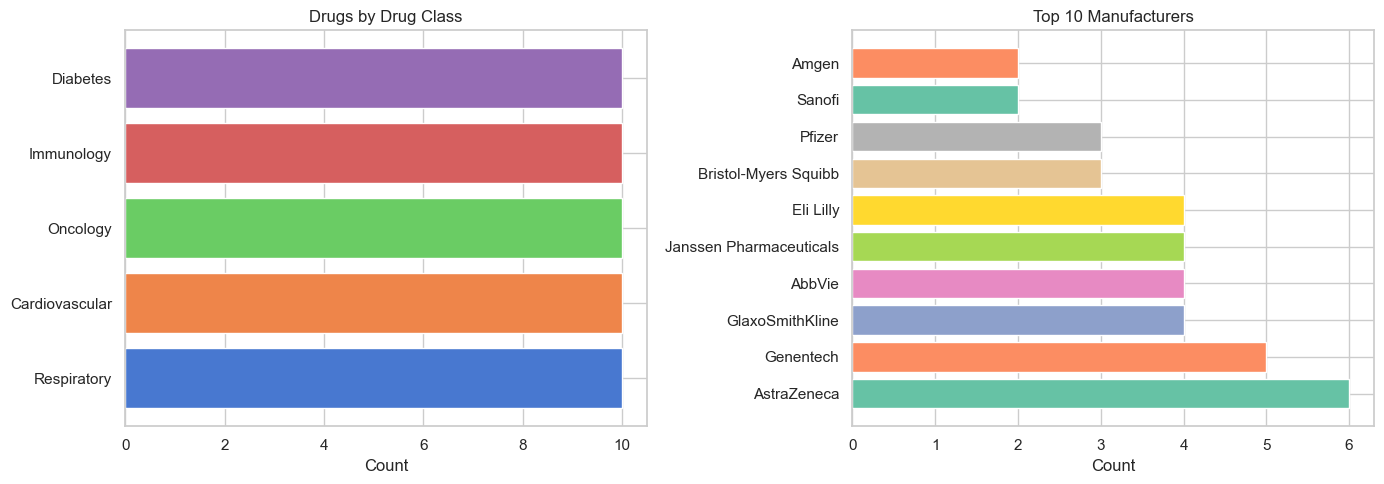

In [4]:
"""
Drug Class & Manufacturer Distribution
"""
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Drug class distribution
dc_counts = catalog['drug_class'].value_counts()
axes[0].barh(dc_counts.index, dc_counts.values, color=sns.color_palette('muted', len(dc_counts)))
axes[0].set_title('Drugs by Drug Class')
axes[0].set_xlabel('Count')

# Manufacturer distribution
mfg_counts = catalog['manufacturer'].value_counts().head(10)
axes[1].barh(mfg_counts.index, mfg_counts.values, color=sns.color_palette('Set2', len(mfg_counts)))
axes[1].set_title('Top 10 Manufacturers')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

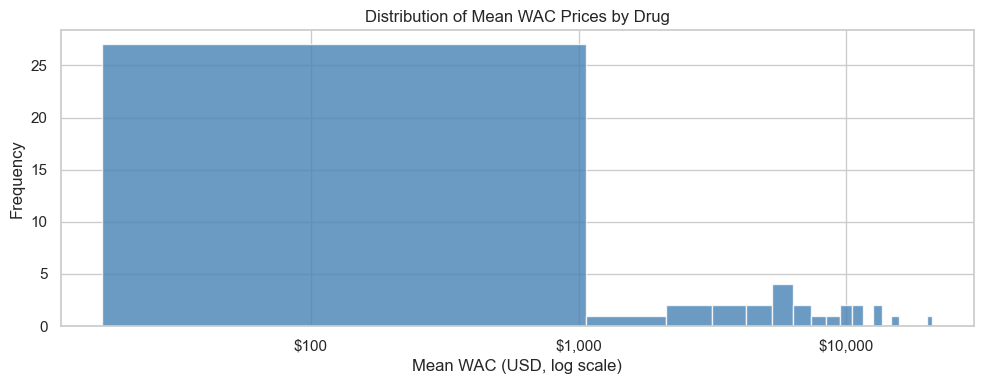

In [5]:
"""
WAC Distribution (log scale)
"""
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(catalog['wac_mean'], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_xscale('log')
ax.set_xlabel('Mean WAC (USD, log scale)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Mean WAC Prices by Drug')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

## 4. Price History EDA

In [6]:
"""
Price History Overview
"""
ph = df.copy()
ph['transaction_date'] = pd.to_datetime(ph['transaction_date'])

print('=== Price History — First 5 Rows ===')
display(ph.head())

print('\n=== Null Value Counts ===')
print(ph.isnull().sum())

print(f'\nTotal transactions: {len(ph)}')

=== Price History — First 5 Rows ===


,drug_id,drug_name,ndc_code,manufacturer,drug_class,pharmacy_id,pharmacy_name,pharmacy_chain,state,wac_price,asp_price,amp_price,price_340b,gtn_price,nadac_price,actual_price,margin_percent,transaction_date,volume_units,is_anomaly,anomaly_type
0,DRG019,Brilinta,16023-1247-13,AstraZeneca,Cardiovascular,PH0008,CVS — Lake Roberto,CVS,WA,354.72,334.54,298.15,258.24,262.93,308.52,321.64,3.86,2025-01-28,232,False,None
1,DRG046,Nucala,24582-1598-16,GlaxoSmithKline,Respiratory,PH0200,Stewart Pharmacy,Independent,NJ,"3,244.83","3,079.48","2,814.06","2,182.04","1,980.24","2,910.02","2,831.71",8.05,2025-09-20,163,False,None
2,DRG025,Revlimid,17925-1325-11,Bristol-Myers Squibb,Oncology,PH0021,CVS — South Noah,CVS,GA,"21,725.76","20,397.34","18,298.58","15,856.41","15,825.78","18,912.25","18,986.58",6.92,2025-02-18,3,False,None
3,DRG035,Dupixent,21095-1455-13,Sanofi,Immunology,PH0197,Beck Pharmacy,Independent,PA,"3,898.01","3,606.64","3,263.36","2,830.32","2,507.59","3,335.13","3,287.47",8.85,2025-05-10,10,False,None
4,DRG023,Herceptin,17291-1299-17,Genentech,Oncology,PH0008,CVS — Lake Roberto,CVS,WA,"6,545.48","6,127.74","5,675.47","4,441.16","4,257.14","5,838.82","5,685.90",7.21,2025-07-06,8,False,None



=== Null Value Counts ===
drug_id                 0
drug_name               0
ndc_code                0
manufacturer            0
drug_class              0
pharmacy_id             0
pharmacy_name           0
pharmacy_chain          0
state                   0
wac_price               0
asp_price               0
amp_price               0
price_340b              0
gtn_price               0
nadac_price             0
actual_price            0
margin_percent          0
transaction_date        0
volume_units            0
is_anomaly              0
anomaly_type        13950
dtype: int64

Total transactions: 15000


In [7]:
"""
WAC Trends — Top 5 Most Expensive Drugs
"""
top5_drugs = ph.groupby('drug_name')['wac_price'].max().nlargest(5).index
trend_df = ph[ph['drug_name'].isin(top5_drugs)].sort_values('transaction_date')

fig = px.line(
    trend_df, x='transaction_date', y='wac_price', color='drug_name',
    title='WAC Prices — Top 5 Most Expensive Drugs',
    labels={'wac_price': 'WAC (USD)', 'transaction_date': 'Date', 'drug_name': 'Drug'},
    template='plotly_white'
)
fig.show()

In [8]:
"""
Price Corridor — WAC vs ASP vs AMP vs Net Price
for a single representative drug
"""
sample_drug = catalog.iloc[0]['drug_name']
sample_df = ph[ph['drug_name'] == sample_drug].sort_values('transaction_date')

fig = go.Figure()
for col, colour, name in [
    ('wac_price', '#1F77B4', 'WAC'),
    ('asp_price',     '#FF7F0E', 'ASP'),
    ('amp_price',     '#2CA02C', 'AMP'),
    ('gtn_price',     '#D62728', 'GTN Price'),
    ('price_340b',    '#9467BD', '340B Price'),
]:
    if col in sample_df.columns:
        fig.add_trace(go.Scatter(
            x=sample_df['transaction_date'], y=sample_df[col],
            mode='lines', name=name, line=dict(color=colour)
        ))

fig.update_layout(
    title=f'Price Corridor — {sample_drug}',
    xaxis_title='Transaction Date', yaxis_title='Price (USD)',
    template='plotly_white'
)
fig.show()

## 5. Gross-to-Net Waterfall Analysis

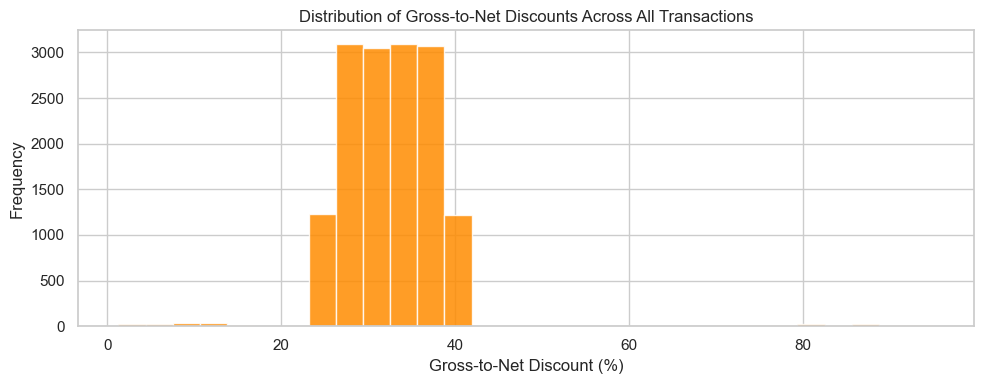

Mean GTN discount:   32.8%
Median GTN discount: 32.5%


In [9]:
"""
Gross-to-Net Distribution
"""
# Calculate GTN percentage as (WAC - GTN) / WAC * 100
ph['gtn_discount_pct'] = ((ph['wac_price'] - ph['gtn_price']) / ph['wac_price'] * 100).clip(0, 100)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(
    ph['gtn_discount_pct'].dropna(),
    bins=30, color='darkorange', edgecolor='white', alpha=0.85
)
ax.set_xlabel('Gross-to-Net Discount (%)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Gross-to-Net Discounts Across All Transactions')
plt.tight_layout()
plt.show()

print(f"Mean GTN discount:   {ph['gtn_discount_pct'].mean():.1f}%")
print(f"Median GTN discount: {ph['gtn_discount_pct'].median():.1f}%")

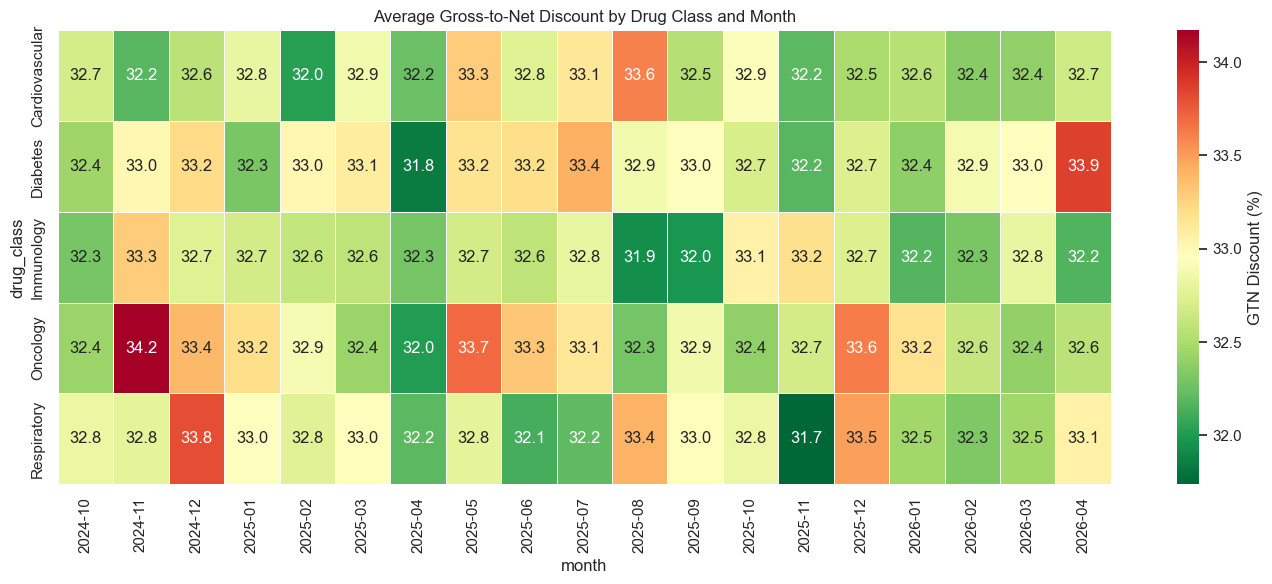

In [11]:
"""
GTN Heatmap — Drug Class × Month
"""
# Drug class is already in ph, just add month and calculate GTN
ph_copy = ph.copy()
ph_copy['month'] = pd.to_datetime(ph_copy['transaction_date']).dt.to_period('M').astype(str)
ph_copy['gtn_discount_pct'] = ((ph_copy['wac_price'] - ph_copy['gtn_price']) / ph_copy['wac_price'] * 100).clip(0, 100)
heatmap = ph_copy.groupby(['drug_class', 'month'])['gtn_discount_pct'].mean().unstack(fill_value=0)

plt.figure(figsize=(14, 6))
sns.heatmap(
    heatmap,
    annot=True, fmt='.1f',
    cmap='RdYlGn_r',
    linewidths=0.5,
    cbar_kws={'label': 'GTN Discount (%)'}
)
plt.title('Average Gross-to-Net Discount by Drug Class and Month')
plt.tight_layout()
plt.show()

## 6. Anomaly Detection

In [12]:
"""
Anomaly Detection Summary
"""
# Use the anomaly flags already present in the data
anomalies_detected = df[df['is_anomaly'] == True]
normal_transactions = df[df['is_anomaly'] == False]

print('=== Anomaly Detection Summary ===')
print(f'  Total transactions: {len(df):,}')
print(f'  Anomalies detected: {len(anomalies_detected):,} ({100*len(anomalies_detected)/len(df):.1f}%)')
print(f'  Normal transactions: {len(normal_transactions):,}')
print(f'\n  Anomaly types:')
for anom_type, count in df[df['is_anomaly']==True]['anomaly_type'].value_counts().items():
    if pd.notna(anom_type):
        print(f'    {anom_type}: {count}')

=== Anomaly Detection Summary ===
  Total transactions: 15,000
  Anomalies detected: 1,050 (7.0%)
  Normal transactions: 13,950

  Anomaly types:
    gtn_deviation: 263
    price_spike: 263
    margin_break: 262
    volume_outlier: 262


In [13]:
"""
Anomaly Visualisation — Transaction scatter
"""
vis_df = df.copy()
vis_df['Status'] = vis_df['is_anomaly'].map({True: 'Anomaly', False: 'Normal'})

fig = px.scatter(
    vis_df, x='transaction_date', y='wac_price',
    color='Status',
    color_discrete_map={'Anomaly': '#EF553B', 'Normal': '#636EFA'},
    hover_data=['drug_name', 'pharmacy_name', 'margin_percent'],
    title='WAC Prices — Anomalies Highlighted',
    labels={'wac_price': 'WAC (USD)', 'transaction_date': 'Date'},
    template='plotly_white',
    opacity=0.7,
)
fig.show()

In [14]:
"""
Anomaly Reason Breakdown
"""
flagged = df[df['is_anomaly'] == True]
reason_counts = flagged['anomaly_type'].value_counts()

fig = px.bar(
    reason_counts.reset_index(),
    x='anomaly_type', y='count',
    title='Anomaly Count by Detection Type',
    labels={'anomaly_type': 'Anomaly Type', 'count': 'Count'},
    template='plotly_white',
    color='count',
    color_continuous_scale='Reds'
)
fig.show()

print('\n=== Top Anomalous Transactions (High/Low Margin) ===')
anomalies_sorted = flagged.sort_values('margin_percent', key=abs, ascending=False)
display(
    anomalies_sorted[['drug_name', 'pharmacy_name', 'wac_price', 'actual_price', 'margin_percent']]
    .head(10)
)


=== Top Anomalous Transactions (High/Low Margin) ===


,drug_name,pharmacy_name,wac_price,actual_price,margin_percent
2680,Jardiance,Walmart — New Thomas,582.12,"2,311.05",-330.00
9592,Jardiance,CVS — North Judithbury,526.97,"2,101.53",-329.87
7877,Brilinta,Kroger — Priceshire,348.23,"1,392.84",-328.99
12203,Revlimid,Walgreens — East Jamesside,"22,444.61","89,270.26",-328.94
6035,Stelara,Walmart — Jeffreyborough,"15,532.34","61,587.21",-328.20
821,Trulicity,Russell Pharmacy,739.73,"2,952.14",-327.26
1294,Keytruda,Kroger — Priceshire,"10,671.50","41,919.42",-326.60
7267,Rituxan,Kroger — New Amanda,"6,404.98","25,162.17",-325.83
12438,Remicade,CVS — East Jill,"5,016.10","20,024.01",-324.46
5466,Lipitor,Walmart — South Rachelborough,33.25,132.46,-324.01


## 7. Competitive Landscape

In [15]:
"""
Drug Pricing Distribution by Drug Class
"""
pricing_summary = df.groupby('drug_class').agg({
    'wac_price': ['mean', 'min', 'max'],
    'gtn_price': 'mean',
    'margin_percent': 'mean'
}).round(2)

display(pricing_summary)

fig = px.box(
    df,
    x='drug_class', y='wac_price',
    title='WAC Price Distribution by Drug Class',
    labels={'wac_price': 'WAC (USD)', 'drug_class': 'Drug Class'},
    template='plotly_white',
    color='drug_class'
)
fig.update_xaxes(tickangle=30)
fig.show()

wac_price                    gtn_price margin_percent
                    mean      min       max      mean           mean
drug_class                                                          
Cardiovascular    275.34     7.92    699.02    185.16          -0.58
Diabetes          566.92    24.74  1,097.53    380.72           0.15
Immunology      7,440.95 2,731.25 17,325.81  5,017.36          -0.04
Oncology        9,793.71 4,720.29 24,615.01  6,569.31           0.28
Respiratory       985.05    19.76  3,466.61    664.97          -0.77

## 8. Key Findings Summary

In [16]:
"""
Key Findings
------------
Programmatic summary of the most important EDA insights.
"""
n_total = len(df)
n_anomalies = (df['is_anomaly'] == True).sum()
median_margin = df['margin_percent'].median()
highest_wac_drug = catalog.loc[catalog['wac_max'].idxmax(), 'drug_name']
highest_wac = catalog['wac_max'].max()
avg_wac = df['wac_price'].mean()
avg_gtn = df['gtn_price'].mean()

print('=' * 60)
print('  PHARMA PRICING COPILOT — KEY EDA FINDINGS')
print('=' * 60)
print(f'  Total transactions:     {n_total:,}')
print(f'  Unique drugs:           {df["drug_name"].nunique()}')
print(f'  Unique pharmacies:      {df["pharmacy_name"].nunique()}')
print(f'  Anomalies detected:     {n_anomalies:,} ({100*n_anomalies/n_total:.1f}%)')
print(f'  Average WAC price:      ${avg_wac:,.2f}')
print(f'  Average GTN price:      ${avg_gtn:,.2f}')
print(f'  Median margin %:        {median_margin:.1f}%')
print(f'  Highest WAC drug:       {highest_wac_drug} (${highest_wac:,.2f})')
print('=' * 60)

  PHARMA PRICING COPILOT — KEY EDA FINDINGS
  Total transactions:     15,000
  Unique drugs:           50
  Unique pharmacies:      199
  Anomalies detected:     1,050 (7.0%)
  Average WAC price:      $3,830.50
  Average GTN price:      $2,575.57
  Median margin %:        4.6%
  Highest WAC drug:       Revlimid ($24,615.01)
